In [1]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('heart_disease_uci.csv')

In [3]:
df['exang'] = df['exang'].map({True: 1, False: 0})
df['fbs'] = df['fbs'].map({True: 1, False: 0})
df['num'] = (df['num'] > 0).astype(int)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    float64
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    float64
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(7), int64(3), object(6)
memory usage: 115.1+ KB


In [5]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,1.0,lv hypertrophy,150.0,0.0,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,0.0,lv hypertrophy,108.0,1.0,1.5,flat,3.0,normal,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,0.0,lv hypertrophy,129.0,1.0,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,0.0,normal,187.0,0.0,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,0.0,lv hypertrophy,172.0,0.0,1.4,upsloping,0.0,normal,0


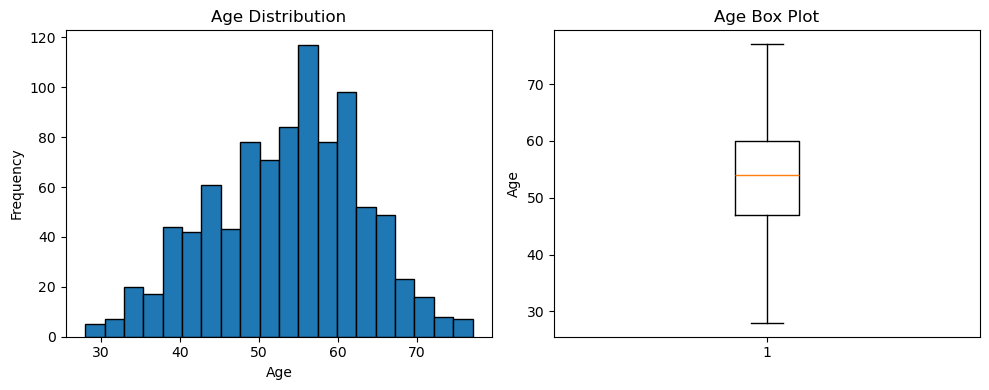

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
ax1.hist(df['age'].dropna(), bins=20, edgecolor='black')
ax1.set_title('Age Distribution')
ax1.set_xlabel('Age')
ax1.set_ylabel('Frequency')

# Box and whisker
ax2.boxplot(df['age'].dropna())
ax2.set_title('Age Box Plot')
ax2.set_ylabel('Age')

plt.tight_layout()
plt.show()

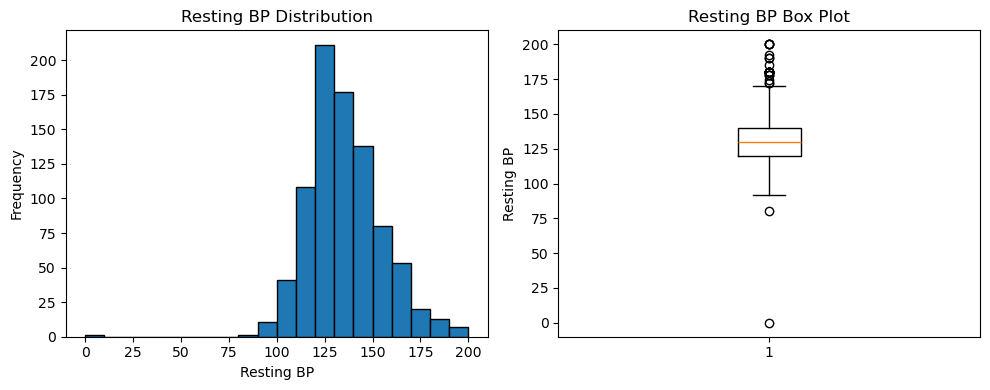

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
ax1.hist(df['trestbps'].dropna(), bins=20, edgecolor='black')
ax1.set_title('Resting BP Distribution')
ax1.set_xlabel('Resting BP')
ax1.set_ylabel('Frequency')

# Box and whisker
ax2.boxplot(df['trestbps'].dropna())
ax2.set_title('Resting BP Box Plot')
ax2.set_ylabel('Resting BP')

plt.tight_layout()
plt.show()

In [8]:
#Seeing how many NaN in the trestbps column

(df['trestbps'] < 2).sum()

np.int64(1)

In [9]:
#Replacing 0 with NaN in trestbps
import numpy as np

df['trestbps'] = df['trestbps'].replace(0, np.nan)

In [10]:
df['trestbps'].mean()

np.float64(132.28604651162792)

In [11]:
#Replacing the NaN data with the Mean value. 

df['trestbps'] = df['trestbps'].fillna(df['trestbps'].mean())

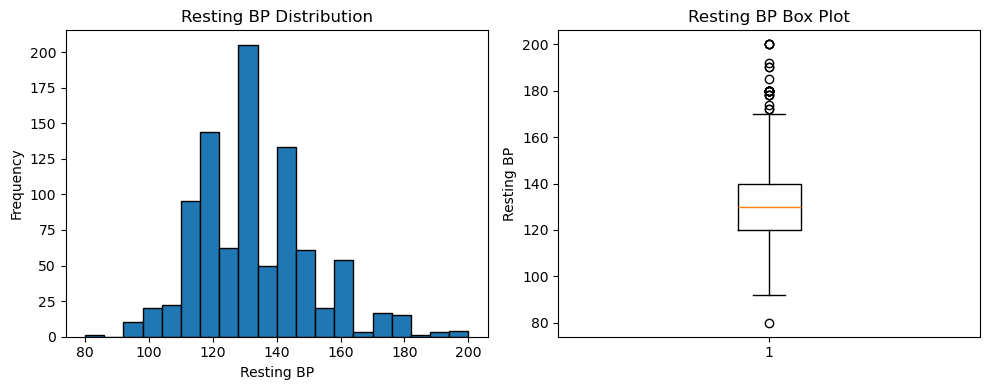

In [12]:
#trestbps after transformation

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
ax1.hist(df['trestbps'].dropna(), bins=20, edgecolor='black')
ax1.set_title('Resting BP Distribution')
ax1.set_xlabel('Resting BP')
ax1.set_ylabel('Frequency')

# Box and whisker
ax2.boxplot(df['trestbps'].dropna())
ax2.set_title('Resting BP Box Plot')
ax2.set_ylabel('Resting BP')

plt.tight_layout()
plt.show()

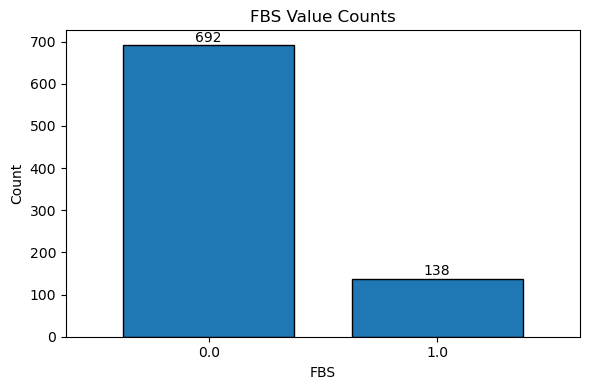

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

counts = df['fbs'].value_counts().sort_index()
counts.plot(kind='bar', ax=ax, edgecolor='black', width=0.75)

for i, v in enumerate(counts):
    ax.text(i, v + 1, str(v), ha='center', va='bottom')

ax.set_title('FBS Value Counts')
ax.set_xlabel('FBS')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
#replacing fbs NaN with 0

df['fbs'] = df['fbs'].fillna(0)

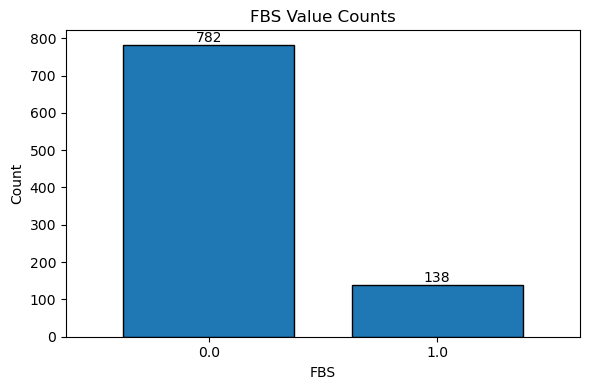

In [15]:
#fbs after transformation

fig, ax = plt.subplots(figsize=(6, 4))

counts = df['fbs'].value_counts().sort_index()
counts.plot(kind='bar', ax=ax, edgecolor='black', width=0.75)

for i, v in enumerate(counts):
    ax.text(i, v + 1, str(v), ha='center', va='bottom')

ax.set_title('FBS Value Counts')
ax.set_xlabel('FBS')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

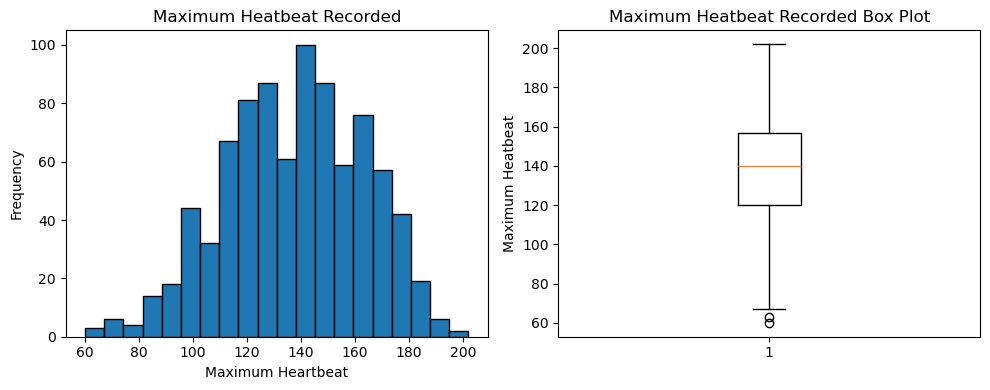

In [16]:
#thalch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
ax1.hist(df['thalch'].dropna(), bins=20, edgecolor='black')
ax1.set_title('Maximum Heatbeat Recorded')
ax1.set_xlabel('Maximum Heartbeat')
ax1.set_ylabel('Frequency')

# Box and whisker
ax2.boxplot(df['thalch'].dropna())
ax2.set_title('Maximum Heatbeat Recorded Box Plot')
ax2.set_ylabel('Maximum Heatbeat')

plt.tight_layout()
plt.show()

In [17]:
df['thalch'].mean()

np.float64(137.5456647398844)

In [18]:
#Replacing the NaN data with the Mean value. 

df['thalch'] = df['thalch'].fillna(df['thalch'].mean())

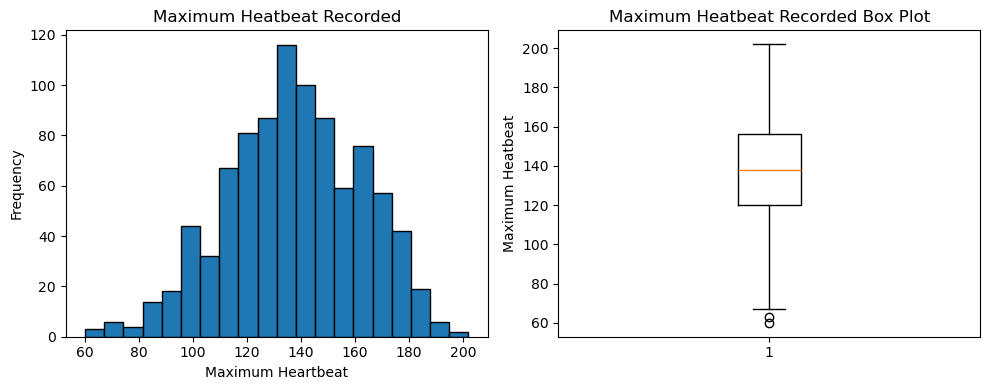

In [19]:
#thalch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
ax1.hist(df['thalch'].dropna(), bins=20, edgecolor='black')
ax1.set_title('Maximum Heatbeat Recorded')
ax1.set_xlabel('Maximum Heartbeat')
ax1.set_ylabel('Frequency')

# Box and whisker
ax2.boxplot(df['thalch'].dropna())
ax2.set_title('Maximum Heatbeat Recorded Box Plot')
ax2.set_ylabel('Maximum Heatbeat')

plt.tight_layout()
plt.show()

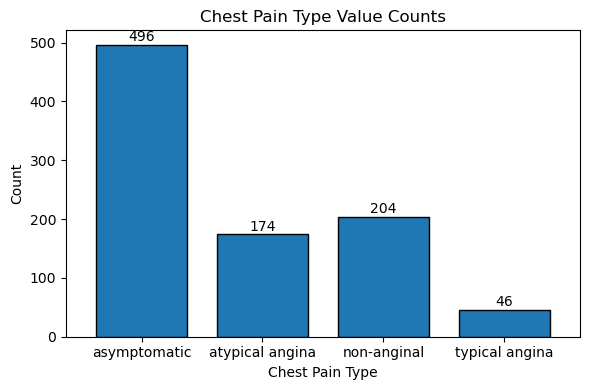

In [20]:
#fbs after transformation

fig, ax = plt.subplots(figsize=(6, 4))

counts = df['cp'].value_counts().sort_index()
counts.plot(kind='bar', ax=ax, edgecolor='black', width=0.75)

for i, v in enumerate(counts):
    ax.text(i, v + 1, str(v), ha='center', va='bottom')

ax.set_title('Chest Pain Type Value Counts')
ax.set_xlabel('Chest Pain Type')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

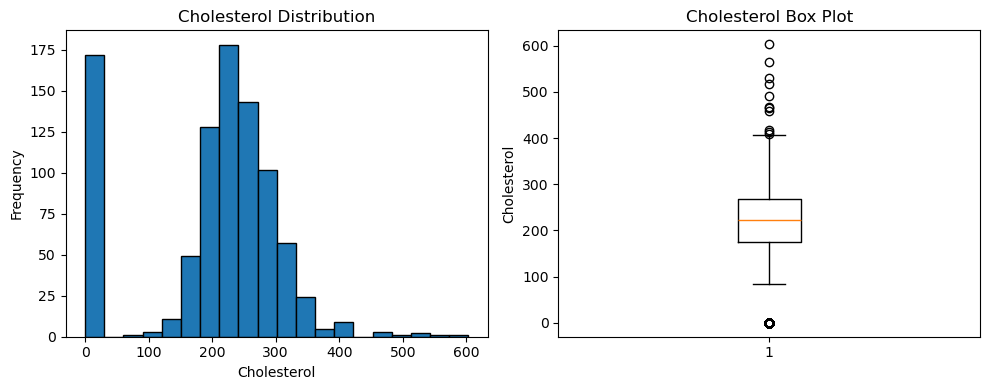

In [21]:
#chol after transformation

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
ax1.hist(df['chol'].dropna(), bins=20, edgecolor='black')
ax1.set_title('Cholesterol Distribution')
ax1.set_xlabel('Cholesterol')
ax1.set_ylabel('Frequency')

# Box and whisker
ax2.boxplot(df['chol'].dropna())
ax2.set_title('Cholesterol Box Plot')
ax2.set_ylabel('Cholesterol')

plt.tight_layout()
plt.show()

In [22]:
#replacing 0 chol with NaN
df['chol'] = df['chol'].replace(0, np.nan)

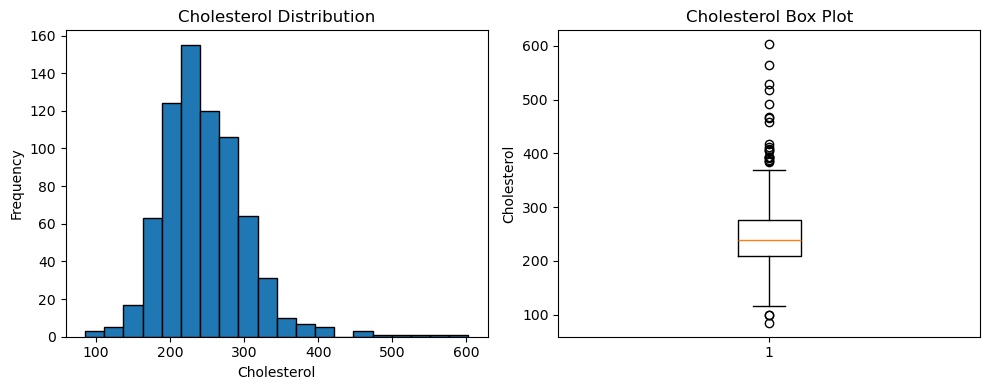

In [23]:
#chol after transformation

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
ax1.hist(df['chol'].dropna(), bins=20, edgecolor='black')
ax1.set_title('Cholesterol Distribution')
ax1.set_xlabel('Cholesterol')
ax1.set_ylabel('Frequency')

# Box and whisker
ax2.boxplot(df['chol'].dropna())
ax2.set_title('Cholesterol Box Plot')
ax2.set_ylabel('Cholesterol')

plt.tight_layout()
plt.show()

In [24]:
df['chol'].median()

239.5

In [25]:
#replacing NaN chol with Median
df['chol'] = df['chol'].fillna(df['chol'].median())

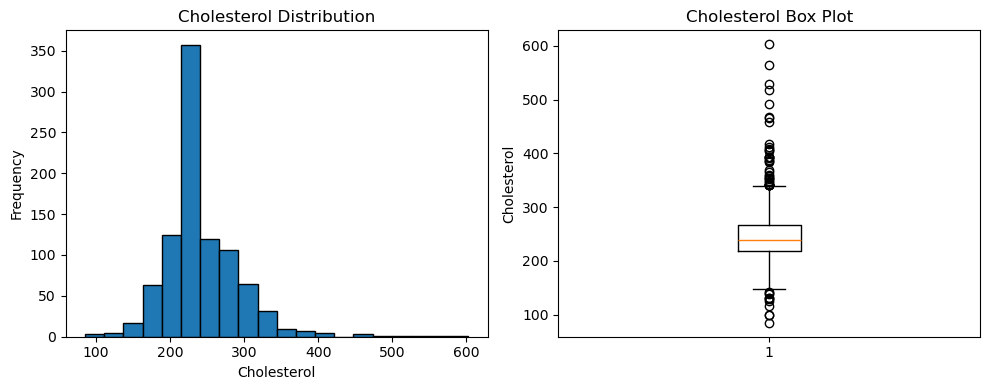

In [26]:
#chol after transformation

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
ax1.hist(df['chol'].dropna(), bins=20, edgecolor='black')
ax1.set_title('Cholesterol Distribution')
ax1.set_xlabel('Cholesterol')
ax1.set_ylabel('Frequency')

# Box and whisker
ax2.boxplot(df['chol'].dropna())
ax2.set_title('Cholesterol Box Plot')
ax2.set_ylabel('Cholesterol')

plt.tight_layout()
plt.show()

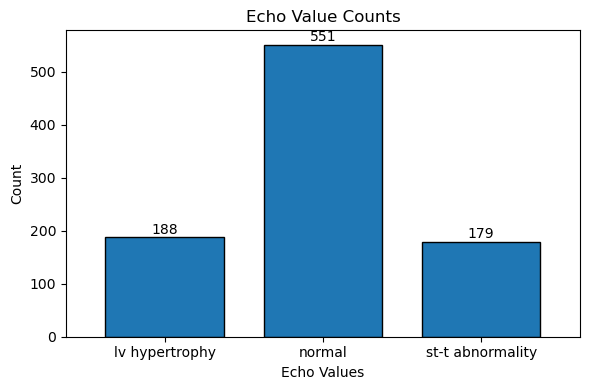

In [27]:
#restecg after transformation

fig, ax = plt.subplots(figsize=(6, 4))

counts = df['restecg'].value_counts().sort_index()
counts.plot(kind='bar', ax=ax, edgecolor='black', width=0.75)

for i, v in enumerate(counts):
    ax.text(i, v + 1, str(v), ha='center', va='bottom')

ax.set_title('Echo Value Counts')
ax.set_xlabel('Echo Values')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
#replacing restecg NaN with 0

df['restecg'] = df['restecg'].fillna('normal')

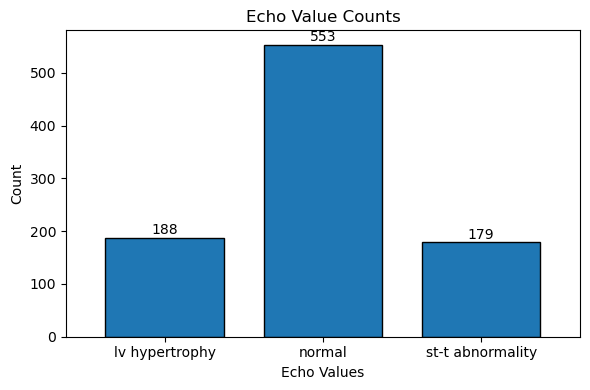

In [29]:
#restecg after transformation

fig, ax = plt.subplots(figsize=(6, 4))

counts = df['restecg'].value_counts().sort_index()
counts.plot(kind='bar', ax=ax, edgecolor='black', width=0.75)

for i, v in enumerate(counts):
    ax.text(i, v + 1, str(v), ha='center', va='bottom')

ax.set_title('Echo Value Counts')
ax.set_xlabel('Echo Values')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

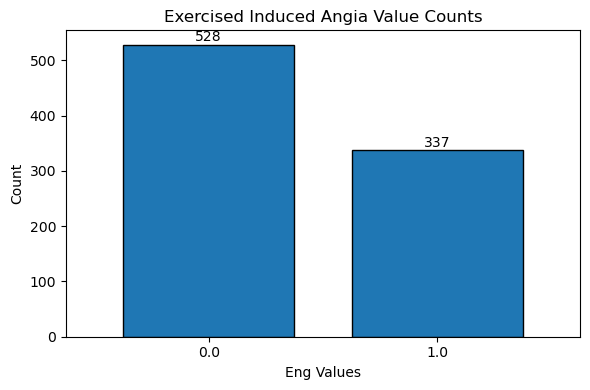

In [30]:
#exang

fig, ax = plt.subplots(figsize=(6, 4))

counts = df['exang'].value_counts().sort_index()
counts.plot(kind='bar', ax=ax, edgecolor='black', width=0.75)

for i, v in enumerate(counts):
    ax.text(i, v + 1, str(v), ha='center', va='bottom')

ax.set_title('Exercised Induced Angia Value Counts')
ax.set_xlabel('Eng Values')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
#Replacing NaN exang with 0

df['exang'] = df['exang'].fillna(0)

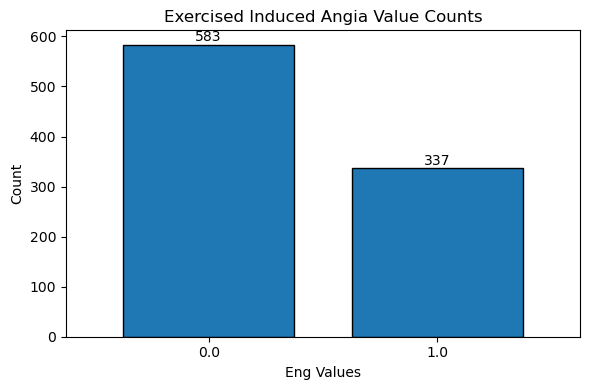

In [32]:
#exang

fig, ax = plt.subplots(figsize=(6, 4))

counts = df['exang'].value_counts().sort_index()
counts.plot(kind='bar', ax=ax, edgecolor='black', width=0.75)

for i, v in enumerate(counts):
    ax.text(i, v + 1, str(v), ha='center', va='bottom')

ax.set_title('Exercised Induced Angia Value Counts')
ax.set_xlabel('Eng Values')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

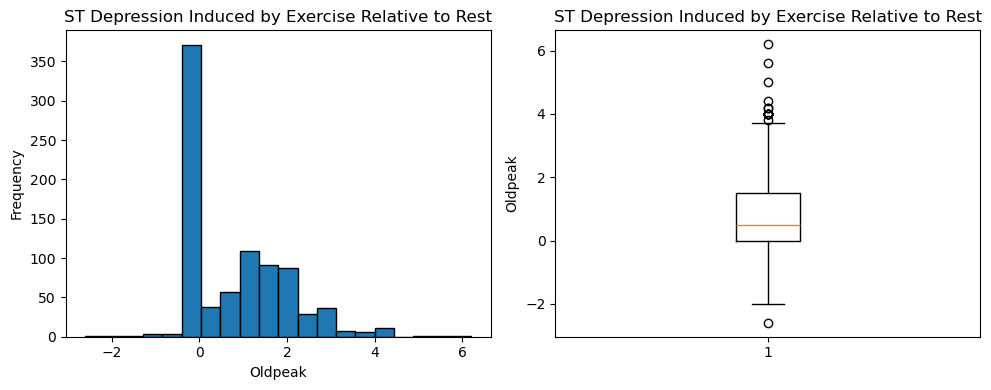

In [33]:
#oldpeak after transformation

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
ax1.hist(df['oldpeak'].dropna(), bins=20, edgecolor='black')
ax1.set_title('ST Depression Induced by Exercise Relative to Rest')
ax1.set_xlabel('Oldpeak')
ax1.set_ylabel('Frequency')

# Box and whisker
ax2.boxplot(df['oldpeak'].dropna())
ax2.set_title('ST Depression Induced by Exercise Relative to Rest')
ax2.set_ylabel('Oldpeak')

plt.tight_layout()
plt.show()

In [34]:
df['oldpeak'].median()

0.5

In [35]:
#replacing NaN oldpeak with Median

df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

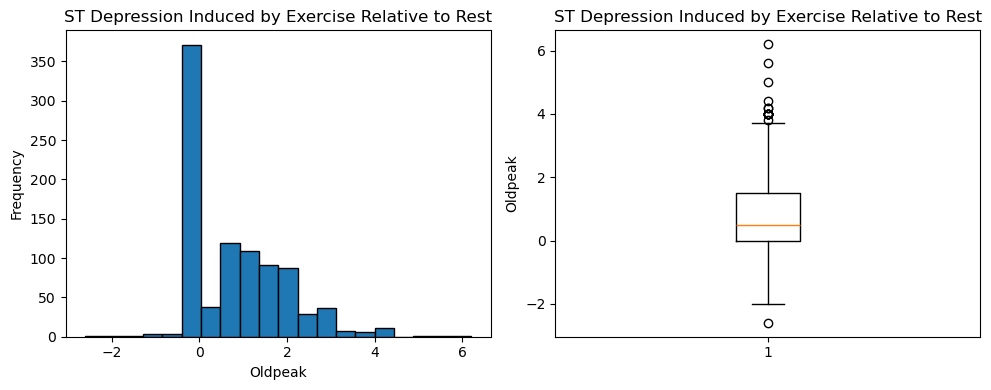

In [36]:
#oldpeak after transformation

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
ax1.hist(df['oldpeak'].dropna(), bins=20, edgecolor='black')
ax1.set_title('ST Depression Induced by Exercise Relative to Rest')
ax1.set_xlabel('Oldpeak')
ax1.set_ylabel('Frequency')

# Box and whisker
ax2.boxplot(df['oldpeak'].dropna())
ax2.set_title('ST Depression Induced by Exercise Relative to Rest')
ax2.set_ylabel('Oldpeak')

plt.tight_layout()
plt.show()

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       920 non-null    float64
 8   restecg   920 non-null    object 
 9   thalch    920 non-null    float64
 10  exang     920 non-null    float64
 11  oldpeak   920 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(7), int64(3), object(6)
memory usage: 115.1+ KB


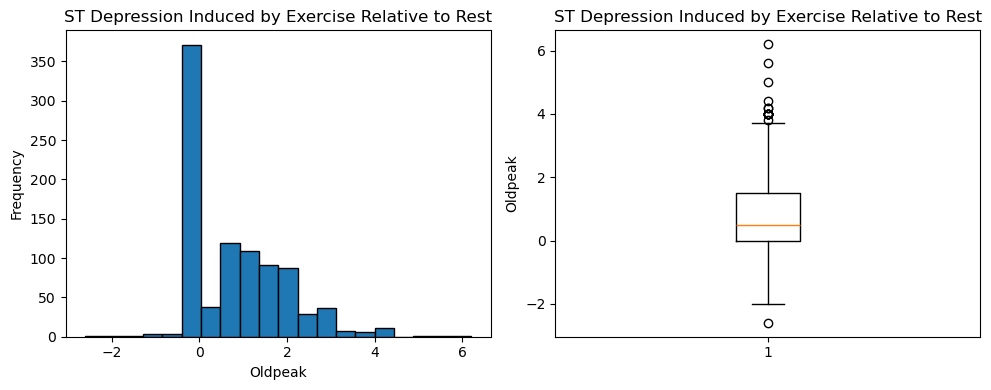

In [38]:
#oldpeak after transformation

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
ax1.hist(df['oldpeak'].dropna(), bins=20, edgecolor='black')
ax1.set_title('ST Depression Induced by Exercise Relative to Rest')
ax1.set_xlabel('Oldpeak')
ax1.set_ylabel('Frequency')

# Box and whisker
ax2.boxplot(df['oldpeak'].dropna())
ax2.set_title('ST Depression Induced by Exercise Relative to Rest')
ax2.set_ylabel('Oldpeak')

plt.tight_layout()
plt.show()

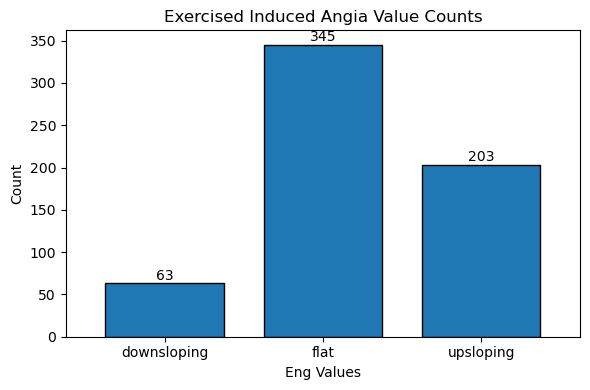

In [39]:
#exang

fig, ax = plt.subplots(figsize=(6, 4))

counts = df['slope'].value_counts().sort_index()
counts.plot(kind='bar', ax=ax, edgecolor='black', width=0.75)

for i, v in enumerate(counts):
    ax.text(i, v + 1, str(v), ha='center', va='bottom')

ax.set_title('Exercised Induced Angia Value Counts')
ax.set_xlabel('Eng Values')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
920 - (63 + 345 + 203)

309

In [41]:
(920-309)/920

0.6641304347826087

In [42]:
df[df['ca'] != '']['slope'].value_counts()

slope
flat           345
upsloping      203
downsloping     63
Name: count, dtype: int64

In [43]:
(920-611)/920

0.3358695652173913

In [44]:
(920-434)/920

0.5282608695652173

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       920 non-null    float64
 8   restecg   920 non-null    object 
 9   thalch    920 non-null    float64
 10  exang     920 non-null    float64
 11  oldpeak   920 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(7), int64(3), object(6)
memory usage: 115.1+ KB


In [46]:
df = df.drop(columns=['id', 'dataset', 'slope', 'ca', 'thal'])

In [47]:
#getting categorical columns

categorical_cols = ['sex', 'cp', 'restecg']
#continuous_cols = df.drop(columns=categorical_cols)

In [48]:
#creating dummy variables
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       920 non-null    int64  
 1   trestbps                  920 non-null    float64
 2   chol                      920 non-null    float64
 3   fbs                       920 non-null    float64
 4   thalch                    920 non-null    float64
 5   exang                     920 non-null    float64
 6   oldpeak                   920 non-null    float64
 7   num                       920 non-null    int64  
 8   sex_Male                  920 non-null    bool   
 9   cp_atypical angina        920 non-null    bool   
 10  cp_non-anginal            920 non-null    bool   
 11  cp_typical angina         920 non-null    bool   
 12  restecg_normal            920 non-null    bool   
 13  restecg_st-t abnormality  920 non-null    bool   
dtypes: bool(6)

In [50]:
#Train / Test Split + SMOTE

from imblearn.over_sampling import SMOTE

X = df.drop(columns=['num'])
y = df['num']

# Train/test split first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check class balance
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_smote).value_counts())

Before SMOTE: num
1    382
0    308
Name: count, dtype: int64
After SMOTE: num
0    382
1    382
Name: count, dtype: int64


In [51]:
y_test.value_counts()

num
1    127
0    103
Name: count, dtype: int64

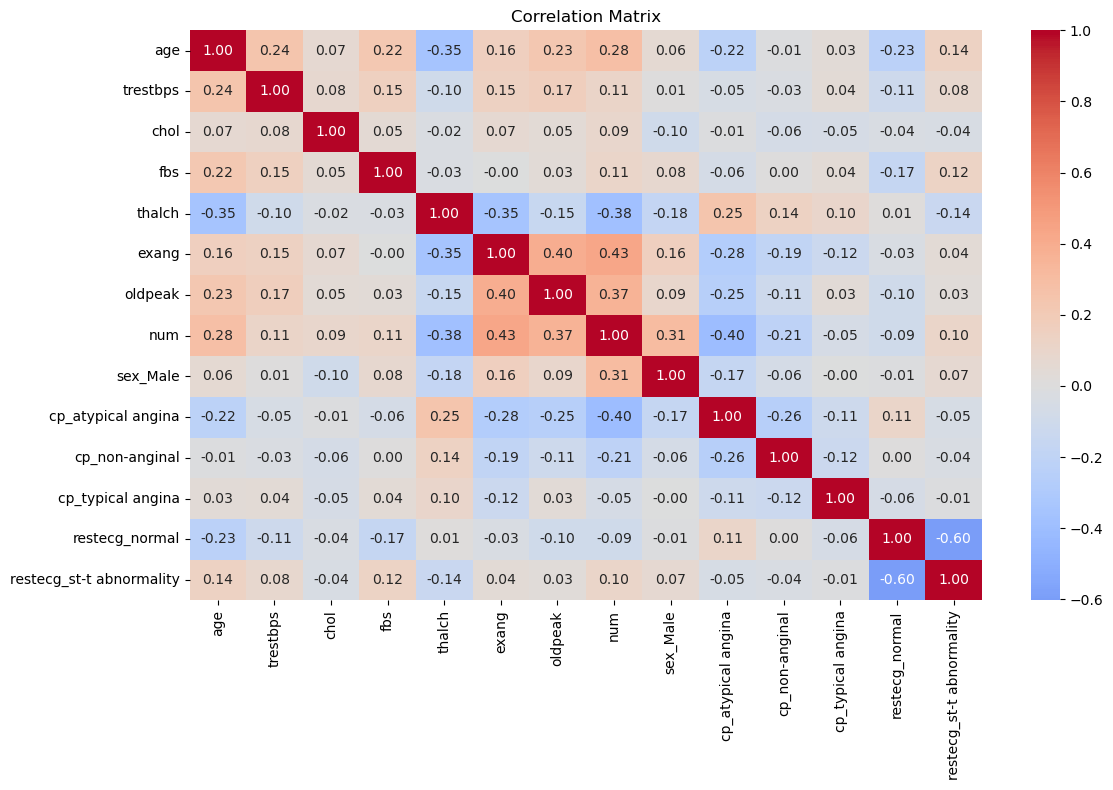

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = df.corr()

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [53]:
#Neural Network

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nn = MLPClassifier(random_state=42, max_iter=1000, activation='relu', hidden_layer_sizes=(100, 50))
nn.fit(X_train_smote, y_train_smote)

y_pred_nn = nn.predict(X_test)

print("Accuracy: ", round(accuracy_score(y_test, y_pred_nn), 2))
print()
print(classification_report(y_test, y_pred_nn))


Accuracy:  0.78

              precision    recall  f1-score   support

           0       0.80      0.67      0.73       103
           1       0.76      0.87      0.81       127

    accuracy                           0.78       230
   macro avg       0.78      0.77      0.77       230
weighted avg       0.78      0.78      0.78       230



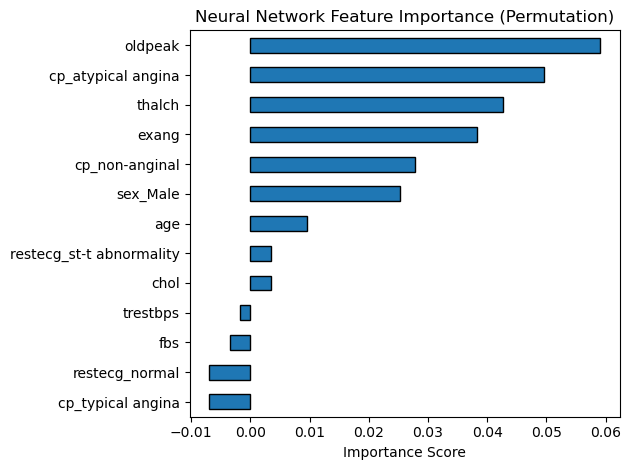

In [54]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(nn, X_test, y_test, random_state=42)

feature_importance = pd.Series(perm.importances_mean, index=X.columns)
feature_importance.sort_values().plot(kind='barh', edgecolor='black')
plt.title('Neural Network Feature Importance (Permutation)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

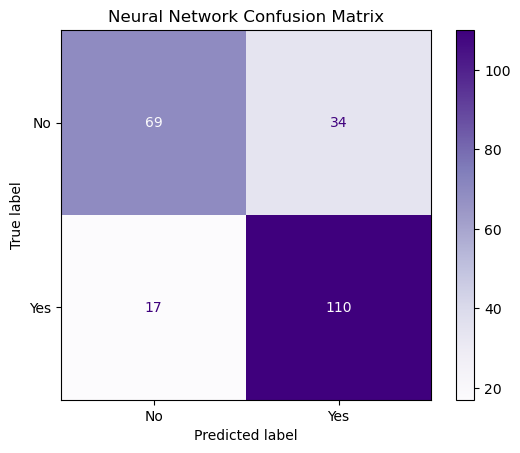

In [55]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Purples')
plt.title('Neural Network Confusion Matrix')
plt.show()

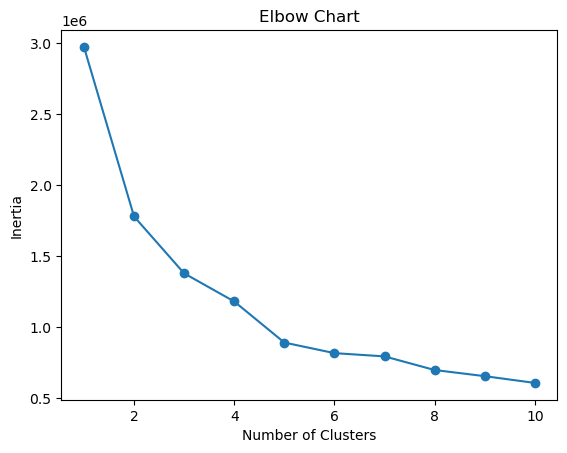

In [58]:
# KM Clustering

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Find optimal number of clusters using elbow method
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_train_smote)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Chart')
plt.show()

In [57]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

# Heart disease rate per cluster
print(df.groupby('cluster')['num'].mean().sort_values())
print()
print(df.groupby('cluster')['num'].value_counts())

cluster
1    0.378601
0    0.550000
2    0.633147
Name: num, dtype: float64

cluster  num
0        1       77
         0       63
1        0      151
         1       92
2        1      340
         0      197
Name: count, dtype: int64
